# INFO 6147 - Pytorch Project - Mustafa Atoof

#### Installs and Imports

In [2]:
!pip install kaggle
!pip install torchcodec
!pip install torchmetrics
!pip install pydub
!sudo apt install ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 21.9 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


Login to kaggle to access the dataset

In [3]:
from google.colab import files
files.upload()   # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


Download the birdsong dataset using the kagglehub.competitions api.

In [4]:
import kagglehub
path = kagglehub.competition_download('birdsong-recognition')

100%|██████████| 22.1G/22.1G [04:26<00:00, 89.2MB/s]

Extracting files...


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchaudio as ta
import torchcodec
from torchmetrics import Accuracy, Precision, Recall, F1Score
from pydub import AudioSegment
import librosa
import librosa.display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import kaggle
import os

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


### Data Loading and Preprocessing

In [6]:
#Device setup
device = ("cuda" if torch.cuda.is_available() else "cpu")

# Set random seed for cpu and gpu
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

Read the metadata csv file

In [7]:
train_csv = pd.read_csv("/root/.cache/kagglehub/competitions/birdsong-recognition/train.csv")
train_csv.head()

,rating,playback_used,ebird_code,channels,date,pitch,duration,filename,speed,species,...,xc_id,url,country,author,primary_label,longitude,length,time,recordist,license
0,3.5,no,aldfly,1 (mono),2013-05-25,Not specified,25,XC134874.mp3,Not specified,Alder Flycatcher,...,134874,https://www.xeno-canto.org/134874,United States,Jonathon Jongsma,Empidonax alnorum_Alder Flycatcher,-92.962,Not specified,8:00,Jonathon Jongsma,Creative Commons Attribution-ShareAlike 3.0
1,4.0,no,aldfly,2 (stereo),2013-05-27,both,36,XC135454.mp3,both,Alder Flycatcher,...,135454,https://www.xeno-canto.org/135454,United States,Mike Nelson,Empidonax alnorum_Alder Flycatcher,-82.1106,0-3(s),08:30,Mike Nelson,Creative Commons Attribution-NonCommercial-Sha...
2,4.0,no,aldfly,2 (stereo),2013-05-27,both,39,XC135455.mp3,both,Alder Flycatcher,...,135455,https://www.xeno-canto.org/135455,United States,Mike Nelson,Empidonax alnorum_Alder Flycatcher,-82.1106,0-3(s),08:30,Mike Nelson,Creative Commons Attribution-NonCommercial-Sha...
3,3.5,no,aldfly,2 (stereo),2013-05-27,both,33,XC135456.mp3,both,Alder Flycatcher,...,135456,https://www.xeno-canto.org/135456,United States,Mike Nelson,Empidonax alnorum_Alder Flycatcher,-82.1106,0-3(s),08:30,Mike Nelson,Creative Commons Attribution-NonCommercial-Sha...
4,4.0,no,aldfly,2 (stereo),2013-05-27,both,36,XC135457.mp3,level,Alder Flycatcher,...,135457,https://www.xeno-canto.org/135457,United States,Mike Nelson,Empidonax alnorum_Alder Flycatcher,-82.1106,0-3(s),08:30,Mike Nelson,Creative Commons Attribution-NonCommercial-Sha...


#### Converting From MP3 to WAV

We convert to wav format because it is uncompressed which helps retain data and consistency when transforming audio into mel spectrograms.

In [8]:
# Method to convert files in mp3 directories into wav files in wav directory
def mp3_to_wav(input_dir, output_dir):
  print(f"Converting files in {input_dir}")
  for filename in os.listdir(input_dir):
    if filename.endswith(".mp3"):
      mp3_path = os.path.join(input_dir, filename)
      wav_filename = filename.replace(".mp3", ".wav")
      wav_path = os.path.join(output_dir, wav_filename)
      # Try to convert if valid file, else skip if invalid
      try:
          # Load MP3 as tensor
          waveform, sr = ta.load(mp3_path)

          # Save as WAV
          ta.save(wav_path, waveform, sr)
      except Exception as e:
        print(f"Skipping {mp3_path}: {e}")

# ****** CONVERT MP3 TO WAV ****** #

birdsong_dir = "/root/.cache/kagglehub/competitions/birdsong-recognition"
train_mp3_dir = os.path.join(birdsong_dir, "train_audio")

# Create the directory to place the wav files in
train_wav_dir = os.path.join(birdsong_dir, "train_wav")
os.makedirs(train_wav_dir, exist_ok=True)

for species in tqdm(os.listdir(train_mp3_dir), desc="Converting mp3 files to wav format"):
  # Create the species directory in wav directory
  mp3_species_dir = os.path.join(train_mp3_dir, species)
  wav_species_dir = os.path.join(train_wav_dir, species)
  os.makedirs(wav_species_dir, exist_ok=True)
  mp3_to_wav(mp3_species_dir, wav_species_dir)

# ****** GET WAV FILES AND LABELS ****** #

audio_paths = []
labels = []
# We need to get the data into a format of {file, label} to map the species labels with the audio files
for species in tqdm(os.listdir(train_wav_dir), desc="Loading Song Directory"):
  # Get species file path and append it to the dir
  species_dir = os.path.join(train_wav_dir, species)
  if os.path.isdir(species_dir):
    for fname in os.listdir(species_dir):
      if fname.endswith(".wav"):
        audio_paths.append(os.path.join(species_dir, fname))
        labels.append(species)

Converting mp3 files to wav format:   0%|          | 0/264 [00:00<?, ?it/s]

Converting files in /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/lesnig
Skipping /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/lesnig/XC243802.mp3: Failed to decode audio samples: Could not push packet to decoder: Invalid data found when processing input


Converting mp3 files to wav format:   0%|          | 1/264 [00:04<18:06,  4.13s/it]

Converting files in /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/scatan
Skipping /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/scatan/XC372787.mp3: Failed to decode audio samples: Could not push packet to decoder: Invalid data found when processing input
Skipping /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/scatan/XC363656.mp3: Failed to decode audio samples: Could not push packet to decoder: Invalid data found when processing input


Converting mp3 files to wav format:   1%|          | 2/264 [00:18<44:05, 10.10s/it]

...

Converting mp3 files to wav format:  99%|█████████▉| 262/264 [41:30<00:19,  9.75s/it]

Converting files in /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/belspa2


Converting mp3 files to wav format: 100%|█████████▉| 263/264 [41:41<00:09,  9.96s/it]

Converting files in /root/.cache/kagglehub/competitions/birdsong-recognition/train_audio/gocspa


Loading Song Directory: 100%|██████████| 264/264 [00:00<00:00, 7385.08it/s]


#### Dataset Definition

Here, we define the dataset object and perform the necessary transformations to get a valid spectrogram.

Key attributes:
- Sample Rate - how many audio samples per second to take (default = 16000 Hz)
- Duration - length of audio recording (default = 5 seconds)
- Number of Mel Bins - How many mel frequency bands (y-axis) the spectrogram is divided into (ddefault = 80, usual range is between 40 to 120)
- Max frames - maximum number of time frames (x-axis) of the spectrogram, this is related to the duration and sample rate (default = 313)

In [9]:
class BirdSongDataset(Dataset):
  def __init__(self, audio_files, labels, sr=16000, duration=5, n_mels=80, max_frames=313):
    # Defining attributes of audio file and spectrogram
    self.audio_files = audio_files # audio file given
    self.labels = labels # labels of each samples
    self.sr = sr # sampling rate
    self.duration = duration # duration of audio
    self.n_mels = n_mels # number of mel filterbanks
    self.max_frames = max_frames #
    # First transform to a Mel Spectrogram
    self.transform = ta.transforms.MelSpectrogram(sample_rate=sr,
                                                  n_mels=n_mels,
                                                  power=2.0)

    # Second transform to change power scale of Mel Sepctrogram to decibel scale (makes the image correspond more to human hearing )
    self.db_transform = ta.transforms.AmplitudeToDB(stype="power",
                                                    top_db=80)

  def __len__(self):
    return (len(self.audio_files))

  def __getitem__(self, idx):
    audio_file = self.audio_files[idx]
    label = self.labels[idx]

    # Load the wav file and do transformations
    # waveform is tensor of shape [channels, samples]
    waveform, sr_orig = ta.load(audio_file)

    # Resample the audio to new sample rate
    waveform = ta.functional.resample(waveform, orig_freq=sr_orig, new_freq=self.sr)

    # Select only specified duration from the total
    num_samples = int(self.sr * self.duration)
    # If audio is shorter than specified duration, pad with zeros to duration, else truncate audio to duration
    if waveform.shape[1] < num_samples:
      pad_samples = num_samples - waveform.shape[1]
      waveform = torch.nn.functional.pad(waveform, (0, pad_samples))
    else:
      waveform = waveform[:, : num_samples]

    # Change audio to mono
    waveform = waveform.mean(dim=0, keepdim=True)

    # mel spec is tensor with shape [channels, n_mels, time]
    mel_spec = self.transform(waveform)

    # Normalize the Mel-Spectrogram
    mel_spec = (mel_spec - mel_spec.mean()) / mel_spec.std()

    # Pad the spectrogram if it is less than max_frames, else clip to max_frames
    if mel_spec.shape[2] < self.max_frames:
      padding = self.max_frames - mel_spec.shape[2]
      if padding > 0:
        mel_spec = torch.nn.functional.pad(
        mel_spec, (0, padding), mode="constant", value=0
    )
    else:
      mel_spec = mel_spec[..., : self.max_frames]

    # Convert power scale to db scale
    mel_spec_db = self.db_transform(mel_spec)

    return mel_spec_db, label


#### Splitting Data and Creating Data Loaders

In [10]:
# Encode the labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# Full dataset distribution
print("Full dataset:", Counter(labels_encoded))

# Create the dataset object
dataset = BirdSongDataset(audio_files=audio_paths, labels=labels_encoded)

# Create dataset splits with ratios 80% - 10% - 10%
train_idx, temp_idx = train_test_split(range(len(labels_encoded)),
                                       test_size=0.2, stratify=labels_encoded,
                                       random_state=seed)

val_idx, test_idx = train_test_split(temp_idx, test_size=0.5,
                                     stratify=[labels_encoded[i] for i in temp_idx],
                                     random_state=seed)

train_data = Subset(dataset, train_idx)
val_data = Subset(dataset, val_idx)
test_data = Subset(dataset, test_idx)

batch_size = 64
# DataLoader Setup
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

Full dataset: Counter({np.int64(199): 100, np.int64(149): 100, np.int64(146): 100, np.int64(184): 100, np.int64(29): 100, np.int64(224): 100, np.int64(240): 100, np.int64(112): 100, np.int64(17): 100, np.int64(51): 100, np.int64(100): 100, np.int64(84): 100, np.int64(213): 100, np.int64(245): 100, np.int64(63): 100, np.int64(247): 100, np.int64(78): 100, np.int64(31): 100, np.int64(168): 100, np.int64(73): 100, np.int64(125): 100, np.int64(97): 100, np.int64(249): 100, np.int64(39): 100, np.int64(0): 100, np.int64(250): 100, np.int64(54): 100, np.int64(177): 100, np.int64(143): 100, np.int64(257): 100, np.int64(152): 100, np.int64(262): 100, np.int64(156): 100, np.int64(61): 100, np.int64(233): 100, np.int64(12): 100, np.int64(48): 100, np.int64(228): 100, np.int64(252): 100, np.int64(33): 100, np.int64(25): 100, np.int64(93): 100, np.int64(45): 100, np.int64(4): 100, np.int64(148): 100, np.int64(50): 100, np.int64(222): 100, np.int64(210): 100, np.int64(79): 100, np.int64(157): 100, n

#### Show Mel Spectrogram Samples

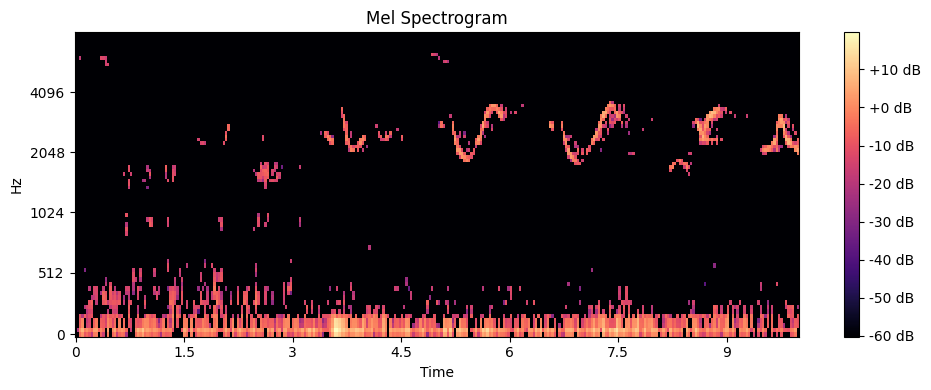

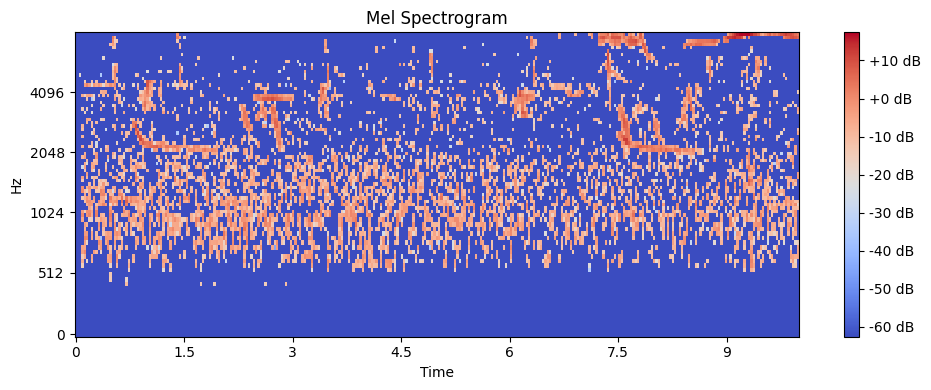

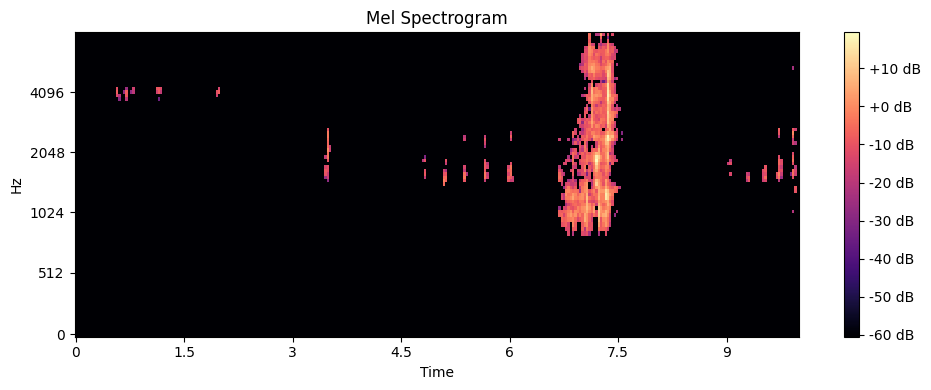

In [32]:
train_iter = iter(train_loader)
mel_batch, _ = next(train_iter)
sr = 16000

for i in range(3):
  mel_spec = mel_batch[i]
  mel_spec = mel_spec.squeeze(0)

  plt.figure(figsize=(10,4))
  librosa.display.specshow(mel_spec.numpy(), sr=sr, x_axis='time', y_axis='mel')
  plt.colorbar(format='%+2.0f dB')
  plt.title("Mel Spectrogram")
  plt.tight_layout()
  plt.show()

## Model Training

This section includes helper functions for loading saved models, saving models, training the model and getting metrics.

The model is then trained and the results of each epoch are printed. A convergence plot is shown to show how the model is over or underfitting.

In [12]:
# Method to save a model in between epochs - saves model parameters, optimizer, scheduler, epoch #, training history
def save_checkpoint(model, optimizer, scheduler, epoch, history, path="checkpoint.pth"):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved at epoch {epoch} with val_loss {history[-1]["val_loss"]:.3f}")

In [13]:
# This method loads a checkpoint from a file so that the model can continue training
def load_checkpoint(checkpoint_path):
  # Load checkpoint
  checkpoint = torch.load(checkpoint_path, map_location=device)

  # Recreate model
  weights = ResNet18_Weights.IMAGENET1K_V1
  model = resnet18(weights=weights)

  # Change input conv to 1 channel
  model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

  # Freeze resnet layers
  for name, param in model.named_parameters():
      if not name.startswith("fc"):
          param.requires_grad = False

  # Rebuild classifier head
  num_features = model.fc.in_features
  model.fc = nn.Sequential(
      nn.Linear(num_features, 512),
      nn.Dropout(0.3),
      nn.ReLU(),
      nn.Linear(512, num_classes)
  )

  model = model.to(device)

  # Recreate optimizer + scheduler
  optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
  scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5)

  # Load states
  model.load_state_dict(checkpoint["model_state_dict"])
  optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
  scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

  # Load epoch and training history
  epoch = checkpoint["epoch"]
  history = checkpoint["history"]

  return model, optimizer, scheduler, epoch, history


Below, I use torchmetrics to get the macro and weighted metrics (accuracy, precision, recall, f1 score) given predictions and labels. This is used during training and validation to return metrics of the model.

In [14]:
num_classes = len(le.classes_)
accuracy_macro = Accuracy(task="multiclass", average="macro", num_classes=num_classes)
precision_macro = Precision(task="multiclass", average="macro", num_classes=num_classes)
recall_macro = Recall(task="multiclass", average="macro", num_classes=num_classes)
f1_macro = F1Score(task="multiclass", average="macro", num_classes=num_classes)

accuracy_weighted = Accuracy(task="multiclass", average="weighted", num_classes=num_classes)
precision_weighted = Precision(task="multiclass", average="weighted", num_classes=num_classes)
recall_weighted = Recall(task="multiclass", average="weighted", num_classes=num_classes)
f1_weighted = F1Score(task="multiclass", average="weighted", num_classes=num_classes)

def get_metrics(preds, labels):
  # Get macro metrics
  acc_m = accuracy_macro(preds, labels)
  prec_m = precision_macro(preds, labels)
  rec_m = recall_macro(preds, labels)
  f1_m = f1_macro(preds, labels)

  # Get weighted metrics
  acc_w = accuracy_weighted(preds, labels)
  prec_w = precision_weighted(preds, labels)
  rec_w = recall_weighted(preds, labels)
  f1_w = f1_weighted(preds, labels)

  macro_scores = {
      "accuracy": acc_m,
      "precision": prec_m,
      "recall": rec_m,
      "f1": f1_m
  }

  weighted_scores = {
      "accuracy": acc_w,
      "precision": prec_w,
      "recall": rec_w,
      "f1": f1_w
  }

  return {
      "macro_scores": macro_scores,
      "weighted_scores": weighted_scores
      }

This is the main training method for one epoch. It includes training and validation. It loads inputs and labels from the data loader, does a forward pass, gets model outputs, calculates losses and gradients and updates model parameters. Then it does a validation run to evaluate the model on the validation data.

In [15]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device):

  # Initialize losses and predictions for metrics later
  running_loss_train = 0.0
  running_loss_val = 0.0

  train_preds, train_labels = [], []
  val_preds, val_labels = [], []

  # Put model into training mode
  model.train()
  # *----------* TRAINING LOOP *----------*
  for inputs, labels in train_loader:
      batch_size = inputs.size(0)
      # Send tensors to device
      inputs, labels = inputs.to(device), labels.to(device)

      # Zero out the gradients
      optimizer.zero_grad()

      # Get model outputs (forward pass)
      outputs = model(inputs)
      _, preds = torch.max(outputs, dim=1)

      # Calculate losses
      loss = criterion(outputs, labels)

      # Calculate gradients and update parameters
      loss.backward()
      optimizer.step()

      # Add batch loss to running loss
      running_loss_train += loss.item() * batch_size

      # Add preds and labels to list to calculate metrics at end of epoch
      train_preds.append(preds.cpu())
      train_labels.append(labels.cpu())

  # *----------* VALIDATION LOOP *----------*
  # Put model in eval mode
  model.eval()

  with torch.no_grad():
    # Validation loop
    for inputs, labels in val_loader:
      batch_size = inputs.size(0)
      # Send tensors to device
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      # Get class predictions
      _, preds = torch.max(outputs, dim=1)

      # Calculate validation loss
      loss = criterion(outputs, labels)
      running_loss_val += loss.item() * batch_size

      # Append validation preds and labels
      val_preds.append(preds.cpu())
      val_labels.append(labels.cpu())

  # Concatenate predictions/labels
  train_preds = torch.cat(train_preds)
  train_labels = torch.cat(train_labels)

  val_preds = torch.cat(val_preds)
  val_labels = torch.cat(val_labels)

  # Calculate training metrics
  training_metrics = get_metrics(train_preds, train_labels)

  # Calculate validation metrics
  val_metrics = get_metrics(val_preds, val_labels)

  return {
      "training_metrics": training_metrics,
      "val_metrics": val_metrics,
      "training_loss": running_loss_train / len(train_loader.dataset),
      "val_loss": running_loss_val / len(val_loader.dataset)
  }

In [16]:
# This method plots the convergence of training and validation losses based on the model history and number of epochs
def plot_convergence(history, num_epochs):
  epochs = range(1, num_epochs + 1)
  train_losses = []
  val_losses = []
  for i in range(num_epochs):
    train_losses.append(history[i]["training_loss"])
    val_losses.append(history[i]["val_loss"])

  plt.figure(figsize=(8,6))
  plt.plot(epochs, train_losses, "r-", label="Training Loss")
  plt.plot(epochs, val_losses, "b--", label="Validation Loss")

  plt.title("Training vs. Validation Loss Convergence")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [17]:
# This method takes a classification report and sorts by f1 score to get the top n and bottom n classes
def best_worst_f1(report, n=5):
  # Convert report to dataframe
  df = pd.DataFrame(report).T

  # Keep only numeric class rows
  df_num = df[df.index.str.isdigit()].copy()
  df_num.index = df_num.index.astype(int)
  # Sort by F1 score
  df_sorted = df_num.sort_values("f1-score", ascending=False)

  # Get top n and bottom n classes
  best_classes = df_sorted.head(n)[["f1-score", "support"]]
  worst_classes = df_sorted.tail(n)[["f1-score", "support"]]

  return best_classes, worst_classes

def get_evaluation_metrics(labels, preds):
  # Calculate classification report
  report = classification_report(labels, preds,
                               zero_division=0,
                               output_dict=True)
  # Just get and print the average metrics macro and weighted
  macro_avg = report["macro avg"]
  weighted_avg = report["weighted avg"]

  print(f"Macro Averages:\n {macro_avg}")
  print(f"\nWeighted Averages:\n {weighted_avg}")

  # Also print out the best and worst performing classes by f1 score
  top5, bottom5 = best_worst_f1(report)

  print("\nTop 5 classes by F1:")
  print(top5)

  print("\nBottom 5 classes by F1:")
  print(bottom5)

In [18]:
# Method for evaluating the model on the test set, returns all the predictions and labels to be used to get metrics
def evaluate_model(model, test_loader, device="cuda"):
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating Model on Test Set"):
      inputs = inputs.to(device)
      labels = labels.to(device)

      # Get model outputs
      outputs = model(inputs)
      # Get predictions from outputs
      preds = torch.argmax(outputs, dim=1)

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

    get_evaluation_metrics(labels.cpu(), preds.cpu())

### Resnet18 - First Model

Two models were trained. Both models used Resnet18 as a base model and fine-tuned the last fc layers. The major difference is the subset of data that was used to train. This first model trained on the entire dataset, it only trained for 12 epochs. It had 1 hidden layer with 512 neurons. Dropout was used with a rate of 0.3.

-CrossEntropy Loss
-AdamW optimizer
-Learning Rate: 1e-3
-L2 Regularization: 1e-4
-LROnPlateau Scheduler: factor=0.1, patience=5


##### Loading from Checkpoint

In [95]:
resnet_model, optimizer, scheduler, epoch, history = load_checkpoint("/content/resnet_model.pth")

##### Building from Scratch

In [ ]:
# Load the ResNet18 model with pretrained weights
weights = ResNet18_Weights.IMAGENET1K_V1
resnet_model = resnet18(weights=weights)

# My inputs have only 1 channel, so need to change resnet input from 3 to 1
resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Freeze the layers of the resnet model
for param in resnet_model.parameters():
  param.requires_grad = False

# Create two fully connected layers to fine tune
num_features = resnet_model.fc.in_features # number of inputs to the fc layer
num_classes = len(le.classes_) # number of classes in dataset
resnet_model.fc = nn.Sequential(
                      nn.Linear(num_features, 512),
                      nn.Dropout(0.3),
                      nn.ReLU(),
                      nn.Linear(512, num_classes))

# Move the model to device
resnet_model = resnet_model.to(device)

# Inverse frequency weighting
class_weights = compute_class_weight("balanced", classes=np.unique(labels_encoded), y=labels_encoded)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(resnet_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5)

num_epochs = 50
best_val_loss = float("inf")

# for tracking training and validation losses and plotting later
history = []

#### Training Loop

In [ ]:
# Training loop
for epoch in tqdm(range(num_epochs), desc="Training Model", leave=False):
  results = train_model(resnet_model, train_loader, val_loader, criterion, optimizer, scheduler, device)

  print(f"Epoch {epoch+1}/{num_epochs}")
  print(f"  Train Loss: {results['training_loss']:.4f} | Val Loss: {results['val_loss']:.4f}")
  print(f"  Train Metrics: {results['training_metrics']}")
  print(f"  Val Metrics: {results['val_metrics']}")

  history.append(results)

  if results["val_loss"] < best_val_loss:
    best_val_loss = results["val_loss"]
    save_checkpoint(resnet_model, optimizer, scheduler, epoch, history, path="resnet_model.pth")

  scheduler.step(results["val_loss"])


Training Model:   2%|▏         | 1/50 [36:28<29:46:56, 2188.09s/it]

Epoch 1/50
  Train Loss: 5.5440 | Val Loss: 5.3951
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.0070), 'precision': tensor(0.0048), 'recall': tensor(0.0070), 'f1': tensor(0.0041)}, 'weighted_scores': {'accuracy': tensor(0.0080), 'precision': tensor(0.0055), 'recall': tensor(0.0080), 'f1': tensor(0.0047)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0147), 'precision': tensor(0.0047), 'recall': tensor(0.0147), 'f1': tensor(0.0045)}, 'weighted_scores': {'accuracy': tensor(0.0170), 'precision': tensor(0.0053), 'recall': tensor(0.0170), 'f1': tensor(0.0050)}}
Checkpoint saved at epoch 0 with val_loss 5.395


Training Model:   4%|▍         | 2/50 [1:12:01<28:44:30, 2155.64s/it]

Epoch 2/50
  Train Loss: 5.3069 | Val Loss: 5.1365
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.0192), 'precision': tensor(0.0138), 'recall': tensor(0.0192), 'f1': tensor(0.0117)}, 'weighted_scores': {'accuracy': tensor(0.0224), 'precision': tensor(0.0158), 'recall': tensor(0.0224), 'f1': tensor(0.0134)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0380), 'precision': tensor(0.0234), 'recall': tensor(0.0380), 'f1': tensor(0.0206)}, 'weighted_scores': {'accuracy': tensor(0.0453), 'precision': tensor(0.0266), 'recall': tensor(0.0453), 'f1': tensor(0.0244)}}
Checkpoint saved at epoch 1 with val_loss 5.136


Training Model:   6%|▌         | 3/50 [1:47:39<28:02:30, 2147.89s/it]

...

Training Model:  64%|██████▍   | 32/50 [19:02:02<10:43:30, 2145.02s/it]

Epoch 32/50
  Train Loss: 4.2558 | Val Loss: 4.6890
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.1263), 'precision': tensor(0.1016), 'recall': tensor(0.1263), 'f1': tensor(0.0967)}, 'weighted_scores': {'accuracy': tensor(0.1092), 'precision': tensor(0.1088), 'recall': tensor(0.1092), 'f1': tensor(0.0984)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0981), 'precision': tensor(0.0956), 'recall': tensor(0.0981), 'f1': tensor(0.0871)}, 'weighted_scores': {'accuracy': tensor(0.1053), 'precision': tensor(0.1089), 'recall': tensor(0.1053), 'f1': tensor(0.0965)}}


Training Model:  66%|██████▌   | 33/50 [19:37:44<10:07:30, 2144.13s/it]

Epoch 33/50
  Train Loss: 4.2633 | Val Loss: 4.6886
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.1239), 'precision': tensor(0.1017), 'recall': tensor(0.1239), 'f1': tensor(0.0952)}, 'weighted_scores': {'accuracy': tensor(0.1069), 'precision': tensor(0.1097), 'recall': tensor(0.1069), 'f1': tensor(0.0973)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0971), 'precision': tensor(0.1015), 'recall': tensor(0.0971), 'f1': tensor(0.0870)}, 'weighted_scores': {'accuracy': tensor(0.1043), 'precision': tensor(0.1158), 'recall': tensor(0.1043), 'f1': tensor(0.0963)}}


KeyboardInterrupt: 

#### First Model Results

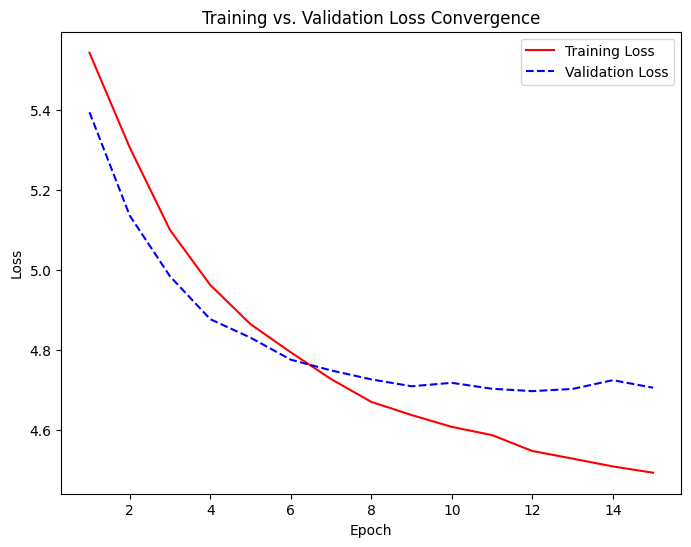

In [54]:
plot_convergence(history, epoch)

In [139]:
evaluate_model(resnet_model, test_loader, device)

Evaluating Model on Test Set: 100%|██████████| 34/34 [04:05<00:00,  7.21s/it]

Macro Averages:
 {'precision': 0.08333333333333333, 'recall': 0.08333333333333333, 'f1-score': 0.08333333333333333, 'support': 7.0}

Weighted Averages:
 {'precision': 0.14285714285714285, 'recall': 0.14285714285714285, 'f1-score': 0.14285714285714285, 'support': 7.0}

Top 5 classes by F1:
    f1-score  support
69       1.0      1.0
31       0.0      2.0
53       0.0      1.0
47       0.0      0.0
58       0.0      0.0

Bottom 5 classes by F1:
     f1-score  support
119       0.0      0.0
132       0.0      1.0
178       0.0      1.0
184       0.0      0.0
233       0.0      1.0


### Resnet 18 - Second Model

This model is similar to the first model, but it trained only on 25% of the dataset, as training was taking too long for the whole dataset. I also changed the hidden layers of the model to have 2 hidden layers with dropout and batchnorm. Batch size was changed as well from 64 to 128 to reduce training times.

#### Loading from Checkpoint

In [22]:
model, optimizer, scheduler, epoch, history = load_checkpoint("/content/model.pth")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


#### Building from Scratch

In [19]:
# Load the ResNet18 model with pretrained weights
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

# My inputs have only 1 channel, so need to change resnet input from 3 to 1
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Freeze the layers of the resnet model
for param in model.parameters():
  param.requires_grad = False

num_features = model.fc.in_features # number of inputs to the fc layer
num_classes = len(le.classes_) # number of classes in dataset

# Model fc head
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, num_classes)
)

model = model.to(device)

The cell below is for creating a subset of the dataset that is 25% of the size.

In [20]:
subset_ratio = 0.25
batch_size = 128
subset_size = int(len(labels_encoded) * subset_ratio)

# Split dataset into subset
subset_idx, _ = train_test_split(
    range(len(labels_encoded)),
    train_size=subset_size,
    stratify=labels_encoded,
    random_state=seed
)

# LAbel encoding
subset_labels = labels_encoded[subset_idx]

# Remove very small classes <2 samples
counts = Counter(subset_labels)
valid_classes = {cls for cls, c in counts.items() if c >= 2}
filtered_idx = [i for i, lbl in zip(subset_idx, subset_labels) if lbl in valid_classes]
filtered_labels = [lbl for lbl in subset_labels if lbl in valid_classes]

# Split into training and temp 70 - 30
train_idx_small, temp_idx_small, train_labels, temp_labels = train_test_split(
    filtered_idx,
    filtered_labels,
    test_size=0.3,
    stratify=filtered_labels,
    shuffle=True,
    random_state=seed
)

# Split temp into val and testing
val_idx_small, test_idx_small = train_test_split(
    temp_idx_small,
    test_size=0.5,
    shuffle=True,
    random_state=seed
)

# Create datasets and dataloaders
small_train_dataset = Subset(dataset, train_idx_small)
small_val_dataset = Subset(dataset, val_idx_small)
small_test_dataset = Subset(dataset, test_idx_small)

small_train_loader = DataLoader(small_train_dataset, batch_size=batch_size, shuffle=True)
small_val_loader = DataLoader(small_val_dataset, batch_size=batch_size, shuffle=False)
small_test_loader = DataLoader(small_test_dataset, batch_size=batch_size, shuffle=False)


#### Second Model Training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5)

num_epochs = 100

# for tracking training and validation losses and plotting later
history = []
best_val_loss = float("inf")

# Training loop
for epoch in tqdm(range(num_epochs), desc="Training Model", leave=False):
  results = train_model(model, small_train_loader, small_val_loader, criterion, optimizer, scheduler, device)

  print(f"Epoch {epoch+1}/{num_epochs}")
  print(f"  Train Loss: {results['training_loss']:.4f} | Val Loss: {results['val_loss']:.4f}")
  print(f"  Train Metrics: {results['training_metrics']}")
  print(f"  Val Metrics: {results['val_metrics']}")

  history.append(results)

  if results["val_loss"] < best_val_loss:
    best_val_loss = results["val_loss"]
    save_checkpoint(model, optimizer, scheduler, epoch, history, path="model.pth")

  scheduler.step(results["val_loss"])

Training Model:   1%|          | 1/100 [08:32<14:06:14, 512.87s/it]

Epoch 1/100
  Train Loss: 5.7106 | Val Loss: 5.4893
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.0036), 'precision': tensor(0.0035), 'recall': tensor(0.0036), 'f1': tensor(0.0027)}, 'weighted_scores': {'accuracy': tensor(0.0043), 'precision': tensor(0.0042), 'recall': tensor(0.0043), 'f1': tensor(0.0033)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0144), 'precision': tensor(0.0035), 'recall': tensor(0.0144), 'f1': tensor(0.0047)}, 'weighted_scores': {'accuracy': tensor(0.0101), 'precision': tensor(0.0029), 'recall': tensor(0.0101), 'f1': tensor(0.0038)}}
Checkpoint saved at epoch 0 with val_loss 5.489


Training Model:   2%|▏         | 2/100 [17:04<13:56:35, 512.20s/it]

Epoch 2/100
  Train Loss: 5.3315 | Val Loss: 5.3580
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.0212), 'precision': tensor(0.0225), 'recall': tensor(0.0212), 'f1': tensor(0.0175)}, 'weighted_scores': {'accuracy': tensor(0.0251), 'precision': tensor(0.0238), 'recall': tensor(0.0251), 'f1': tensor(0.0201)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0224), 'precision': tensor(0.0099), 'recall': tensor(0.0224), 'f1': tensor(0.0108)}, 'weighted_scores': {'accuracy': tensor(0.0239), 'precision': tensor(0.0132), 'recall': tensor(0.0239), 'f1': tensor(0.0139)}}
Checkpoint saved at epoch 1 with val_loss 5.358


Training Model:   3%|▎         | 3/100 [25:36<13:47:37, 511.93s/it]

...

Epoch 9/100
  Train Loss: 4.0335 | Val Loss: 4.9333
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.1586), 'precision': tensor(0.1679), 'recall': tensor(0.1586), 'f1': tensor(0.1419)}, 'weighted_scores': {'accuracy': tensor(0.1829), 'precision': tensor(0.1780), 'recall': tensor(0.1829), 'f1': tensor(0.1595)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0561), 'precision': tensor(0.0317), 'recall': tensor(0.0561), 'f1': tensor(0.0338)}, 'weighted_scores': {'accuracy': tensor(0.0579), 'precision': tensor(0.0389), 'recall': tensor(0.0579), 'f1': tensor(0.0396)}}
Checkpoint saved at epoch 8 with val_loss 4.933


Training Model:  10%|█         | 10/100 [1:25:16<12:37:30, 505.00s/it]

Epoch 10/100
  Train Loss: 3.8912 | Val Loss: 4.8876
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.1837), 'precision': tensor(0.2083), 'recall': tensor(0.1837), 'f1': tensor(0.1723)}, 'weighted_scores': {'accuracy': tensor(0.2080), 'precision': tensor(0.2178), 'recall': tensor(0.2080), 'f1': tensor(0.1895)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0646), 'precision': tensor(0.0424), 'recall': tensor(0.0646), 'f1': tensor(0.0427)}, 'weighted_scores': {'accuracy': tensor(0.0680), 'precision': tensor(0.0537), 'recall': tensor(0.0680), 'f1': tensor(0.0523)}}
Checkpoint saved at epoch 9 with val_loss 4.888


Training Model:  11%|█         | 11/100 [1:33:29<12:23:37, 501.32s/it]

Epoch 11/100
  Train Loss: 3.7202 | Val Loss: 4.8763
  Train Metrics: {'macro_scores': {'accuracy': tensor(0.2119), 'precision': tensor(0.2246), 'recall': tensor(0.2119), 'f1': tensor(0.1993)}, 'weighted_scores': {'accuracy': tensor(0.2395), 'precision': tensor(0.2378), 'recall': tensor(0.2395), 'f1': tensor(0.2206)}}
  Val Metrics: {'macro_scores': {'accuracy': tensor(0.0629), 'precision': tensor(0.0491), 'recall': tensor(0.0629), 'f1': tensor(0.0425)}, 'weighted_scores': {'accuracy': tensor(0.0642), 'precision': tensor(0.0637), 'recall': tensor(0.0642), 'f1': tensor(0.0517)}}
Checkpoint saved at epoch 10 with val_loss 4.876


### Second Model Results

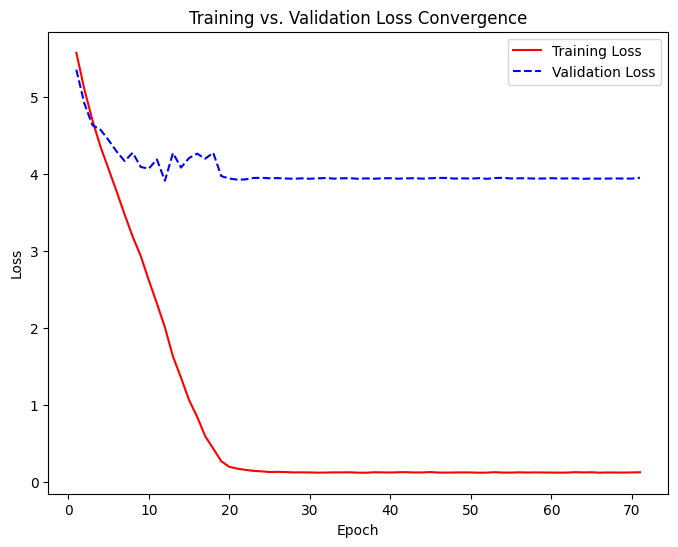

In [92]:
plot_convergence(history, epoch)

In [23]:
evaluate_model(model, test_loader, device)

Evaluating Model on Test Set: 100%|██████████| 34/34 [03:58<00:00,  7.01s/it]

Macro Averages:
 {'precision': 0.08333333333333333, 'recall': 0.08333333333333333, 'f1-score': 0.08333333333333333, 'support': 7.0}

Weighted Averages:
 {'precision': 0.14285714285714285, 'recall': 0.14285714285714285, 'f1-score': 0.14285714285714285, 'support': 7.0}

Top 5 classes by F1:
     f1-score  support
233       1.0      1.0
31        0.0      2.0
69        0.0      1.0
53        0.0      1.0
86        0.0      0.0

Bottom 5 classes by F1:
     f1-score  support
132       0.0      1.0
178       0.0      1.0
220       0.0      0.0
227       0.0      0.0
258       0.0      0.0


## Gradio App

In [ ]:
import gradio as gr
from openai import OpenAI
import requests
import io
import tempfile
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

idx_to_label = {i: label for i, label in enumerate(le.classes_)}

def convert_mp3_to_wav(filepath):
  if not filepath.lower().endswith(".mp3"):
      return filepath  # nothing to do

  wav_path = filepath.replace(".mp3", ".wav")

  try:
    waveform, sr = ta.load(filepath)
    ta.save(wav_path, waveform, sr)
    return wav_path
  except Exception as e:
    print(f"Error converting {filepath}: {e}")
    return None

def preprocess_audio(filepath):
  # Convert mp3 to wav if needed
  wav_filepath = convert_mp3_to_wav(filepath)

  # If conversion failed or file was already wav, use original filepath
  if wav_filepath is None:
      wav_filepath = filepath

  # Build dataset for single file
  data = BirdSongDataset(audio_files=[filepath], labels=[0])
  mel, _ = data[0]

  return mel.unsqueeze(0)

def get_predictions(mel):
  model.eval()
  mel = mel.to(device)
  with torch.no_grad():
    logits = model(mel)
    pred_idx = torch.argmax(logits, dim=1).item()

  species_pred = idx_to_label[pred_idx]
  return species_pred, logits

def generate_species_info(species_name):
  # Define prompt
  prompt = f"Give me a concise informative description of the bird species with eBird code '{species_name}', including habitat, behavior, and distinctive traits, max 500 characters. Write in a neat, informative, and concise way. Treat this as if you are writing a wikipedia article. Write in plain text, no markdown. Start this response with 'Your species is [NAME OF SPECIES]'."

  # Get response from api
  response = client.responses.create(
      model = "gpt-5.2",
      input=prompt,
  )
  # Return the api response text
  return response.output_text

def fetch_ebird_image(species_name):
  url = f"https://search.macaulaylibrary.org/api/v1/search?taxonCode={species_name}&mediaType=photo"
  resp = requests.get(url)
  data = resp.json()
  content = data.get("results", {}).get("content", [])
  if not content:
      return None
  img_url = content[0].get("mediaUrl")
  if not img_url:
      return None

  return img_url

def handle_input(filepath):
  # Preprocess the audio file
  mel = preprocess_audio(filepath)

  # Get species predictions and logits from the model
  species_pred, logits = get_predictions(mel)

  # Get species information from openapi
  bird_info = generate_species_info(species_name=species_pred)

  # Get image of bird url
  bird_img_url = fetch_ebird_image(species_name=species_pred)

  return species_pred, bird_info, bird_img_url

demo = gr.Interface(
  fn=handle_input,
  inputs=gr.Audio(
    sources=["microphone", "upload"],
    type="filepath",
    label="Upload a bird audio file"
  ),
  outputs=[
    gr.Textbox(label="Predicted Bird Species Code"),
    gr.Textbox(label="About This Species", lines=6),
    gr.Textbox(label="Species Photo URL")
  ],
)

demo.launch(share=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>